In [ ]:
# CELL 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

✅ Ready!


In [13]:
# Load all data files - WITH PROPER DATE PARSING

print("Loading all data files...\n")

# Currency data 
df_currency = pd.read_csv('../data/raw/currency_data.csv', 
                          index_col=0, parse_dates=True)
print(f"✓ Currency data: {df_currency.shape[0]:,} rows × {df_currency.shape[1]} columns")

# Economic data 
df_economic = pd.read_csv('../data/raw/economic_indicators.csv', 
                          index_col=0, parse_dates=True)
print(f"✓ Economic data: {df_economic.shape[0]:,} rows × {df_economic.shape[1]} columns")

# Commodity data 
df_commodity = pd.read_csv('../data/raw/commodity_prices.csv', 
                           index_col=0, parse_dates=True)
print(f"✓ Commodity data: {df_commodity.shape[0]:,} rows × {df_commodity.shape[1]} columns")

# EVENT DATA - FIXED WITH PROPER DATE PARSING
df_events = pd.read_csv('../data/raw/event_indicators.csv', 
                        index_col=0, 
                        parse_dates=True,
                        dayfirst=True)  # THIS IS THE FIX!
print(f"✓ Event data: {df_events.shape[0]:,} rows × {df_events.shape[1]} columns")

# Verify dates are actually datetime
print(f"\n Date Types:")
print(f"  Currency index type: {type(df_currency.index)}")
print(f"  Event index type: {type(df_events.index)}")

print(f"\n{'='*70}")
print(" ALL DATA LOADED SUCCESSFULLY!")
print(f"{'='*70}")

Loading all data files...

✓ Currency data: 4,191 rows × 6 columns
✓ Economic data: 4,053 rows × 6 columns
✓ Commodity data: 4,049 rows × 6 columns
✓ Event data: 5,881 rows × 16 columns

 Date Types:
  Currency index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
  Event index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

 ALL DATA LOADED SUCCESSFULLY!


In [3]:
# CELL 3: Explore currency data
print("="*70)
print("CURRENCY DATA OVERVIEW")
print("="*70)
print(df_currency.head())
print("\nBasic Statistics:")
df_currency.describe()

CURRENCY DATA OVERVIEW
              INR_USD   EUR_USD   GBP_USD    JPY_USD  CNY_USD   AUD_USD
Date                                                                   
2010-01-01  46.610001  1.438994  1.613294  92.919998      NaN  0.898473
2010-01-04  46.287998  1.442398  1.611370  92.495003   6.8169  0.912492
2010-01-05  46.119999  1.436596  1.599079  91.584999   6.8170  0.911826
2010-01-06  45.720001  1.440403  1.602384  92.356003   6.8183  0.920471
2010-01-07  45.688000  1.431803  1.593397  93.389999   6.8178  0.917768

Basic Statistics:


,INR_USD,EUR_USD,GBP_USD,JPY_USD,CNY_USD,AUD_USD
count,4190.000000,4190.000000,4190.000000,4190.000000,4188.000000,4189.000000
mean,67.668555,1.186383,1.404231,112.855218,6.659743,0.791360
std,12.357309,0.111760,0.148185,21.902116,0.360506,0.133133
min,43.900002,0.959619,1.072754,75.739998,5.863000,0.574290
25%,60.770750,1.098165,1.279627,101.461500,6.351650,0.686941
50%,67.505802,1.156671,1.351616,109.859001,6.648750,0.747105
75%,75.963673,1.283149,1.553000,123.287500,6.948350,0.902935
max,92.040802,1.484406,1.716090,161.621002,7.350000,1.103497


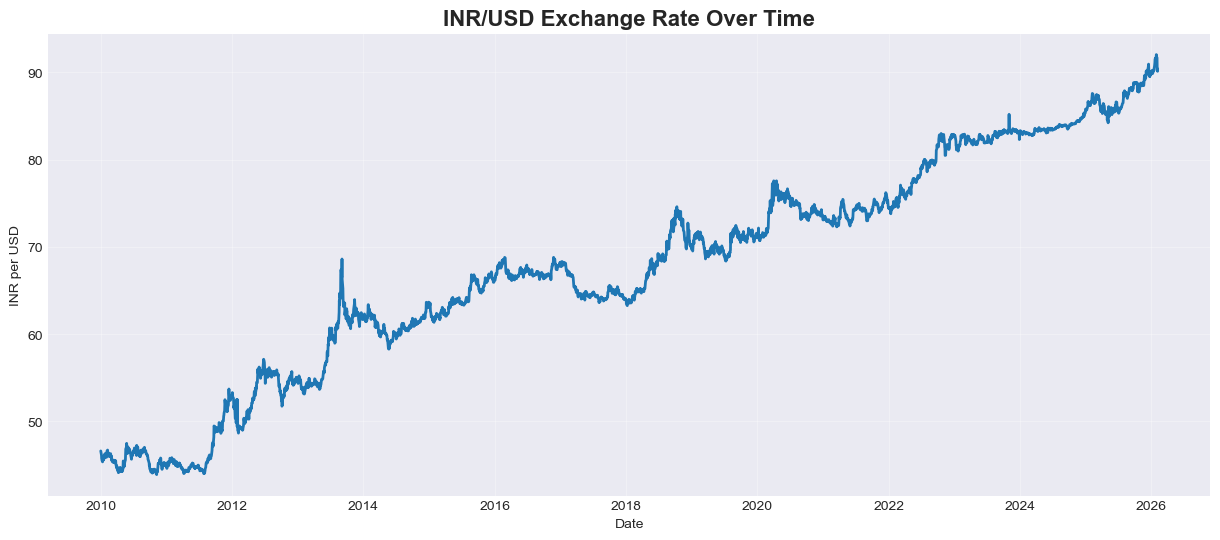

In [4]:
# CELL 4: INR/USD visualization
plt.figure(figsize=(15, 6))
plt.plot(df_currency.index, df_currency['INR_USD'], linewidth=2)
plt.title('INR/USD Exchange Rate Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('INR per USD')
plt.grid(True, alpha=0.3)
plt.show()

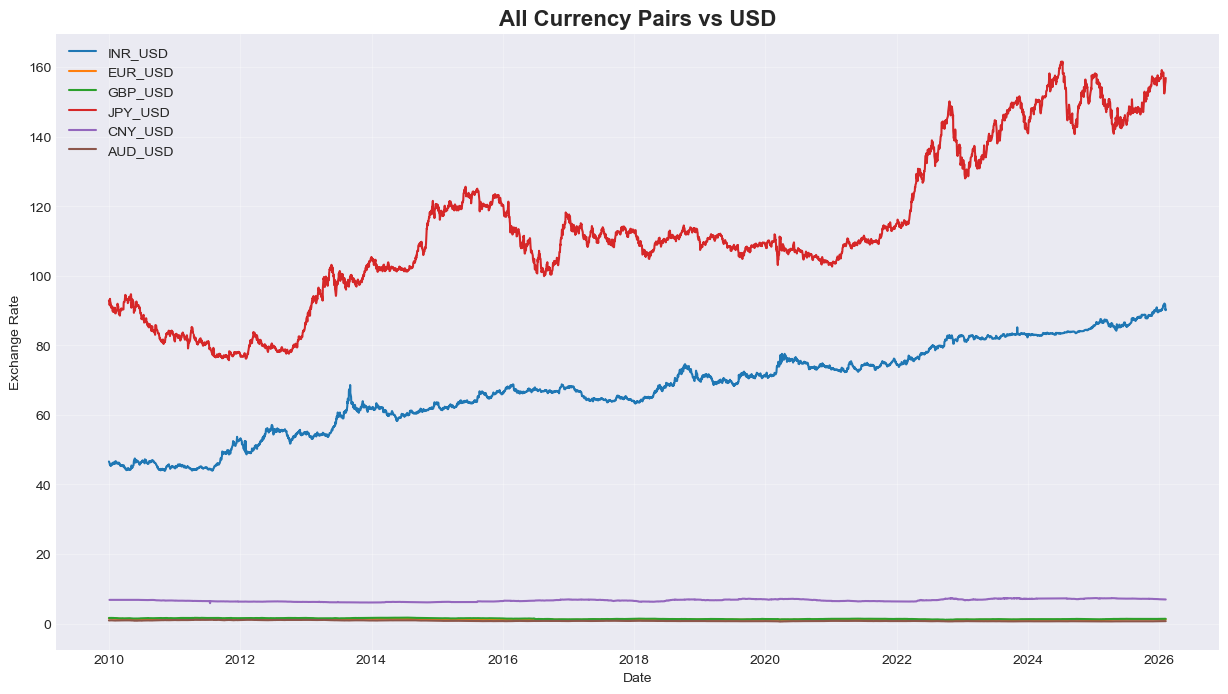

In [5]:
# CELL 5: All currencies comparison
plt.figure(figsize=(15, 8))
for col in df_currency.columns:
    plt.plot(df_currency.index, df_currency[col], label=col, linewidth=1.5)
plt.title('All Currency Pairs vs USD', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

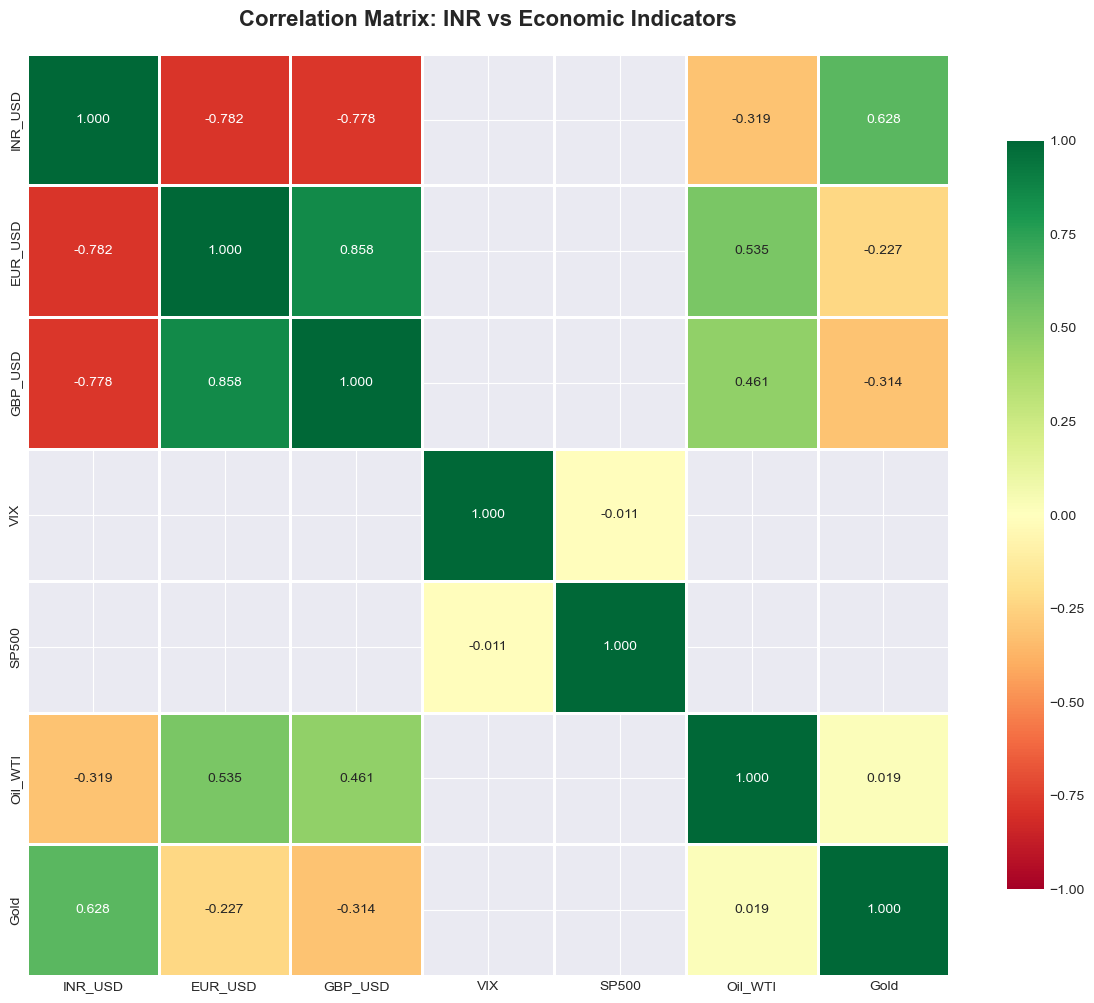


 Top Correlations with INR/USD:
  Gold           : +0.628 (Moderate Positive)
  Oil_WTI        : -0.319 (Weak Negative)
  GBP_USD        : -0.778 (Strong Negative)
  EUR_USD        : -0.782 (Strong Negative)
  VIX            : +nan (Weak Negative)
  SP500          : +nan (Weak Negative)


In [12]:
# Create combined dataset for correlation
analysis_df = pd.DataFrame({
    'INR_USD': df_currency['INR_USD'],
    'EUR_USD': df_currency['EUR_USD'],
    'GBP_USD': df_currency['GBP_USD'],
    'VIX': df_economic['VIX'],
    'SP500': df_economic['SP500'],
    'Oil_WTI': df_commodity['Oil_WTI'],
    'Gold': df_commodity['Gold']
})

# Calculate correlation matrix
correlation = analysis_df.corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, 
            annot=True,  # Show numbers
            fmt='.3f',   # 3 decimal places
            cmap='RdYlGn',  # Red-Yellow-Green colormap
            center=0,    # Center at 0
            square=True, # Square cells
            linewidths=2,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)

plt.title('Correlation Matrix: INR vs Economic Indicators', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n Top Correlations with INR/USD:")
print("="*50)
inr_corr = correlation['INR_USD'].sort_values(ascending=False)
for asset, corr_value in inr_corr.items():
    if asset != 'INR_USD':
        strength = "Strong" if abs(corr_value) > 0.7 else "Moderate" if abs(corr_value) > 0.4 else "Weak"
        direction = "Positive" if corr_value > 0 else "Negative"
        print(f"  {asset:15s}: {corr_value:+.3f} ({strength} {direction})")

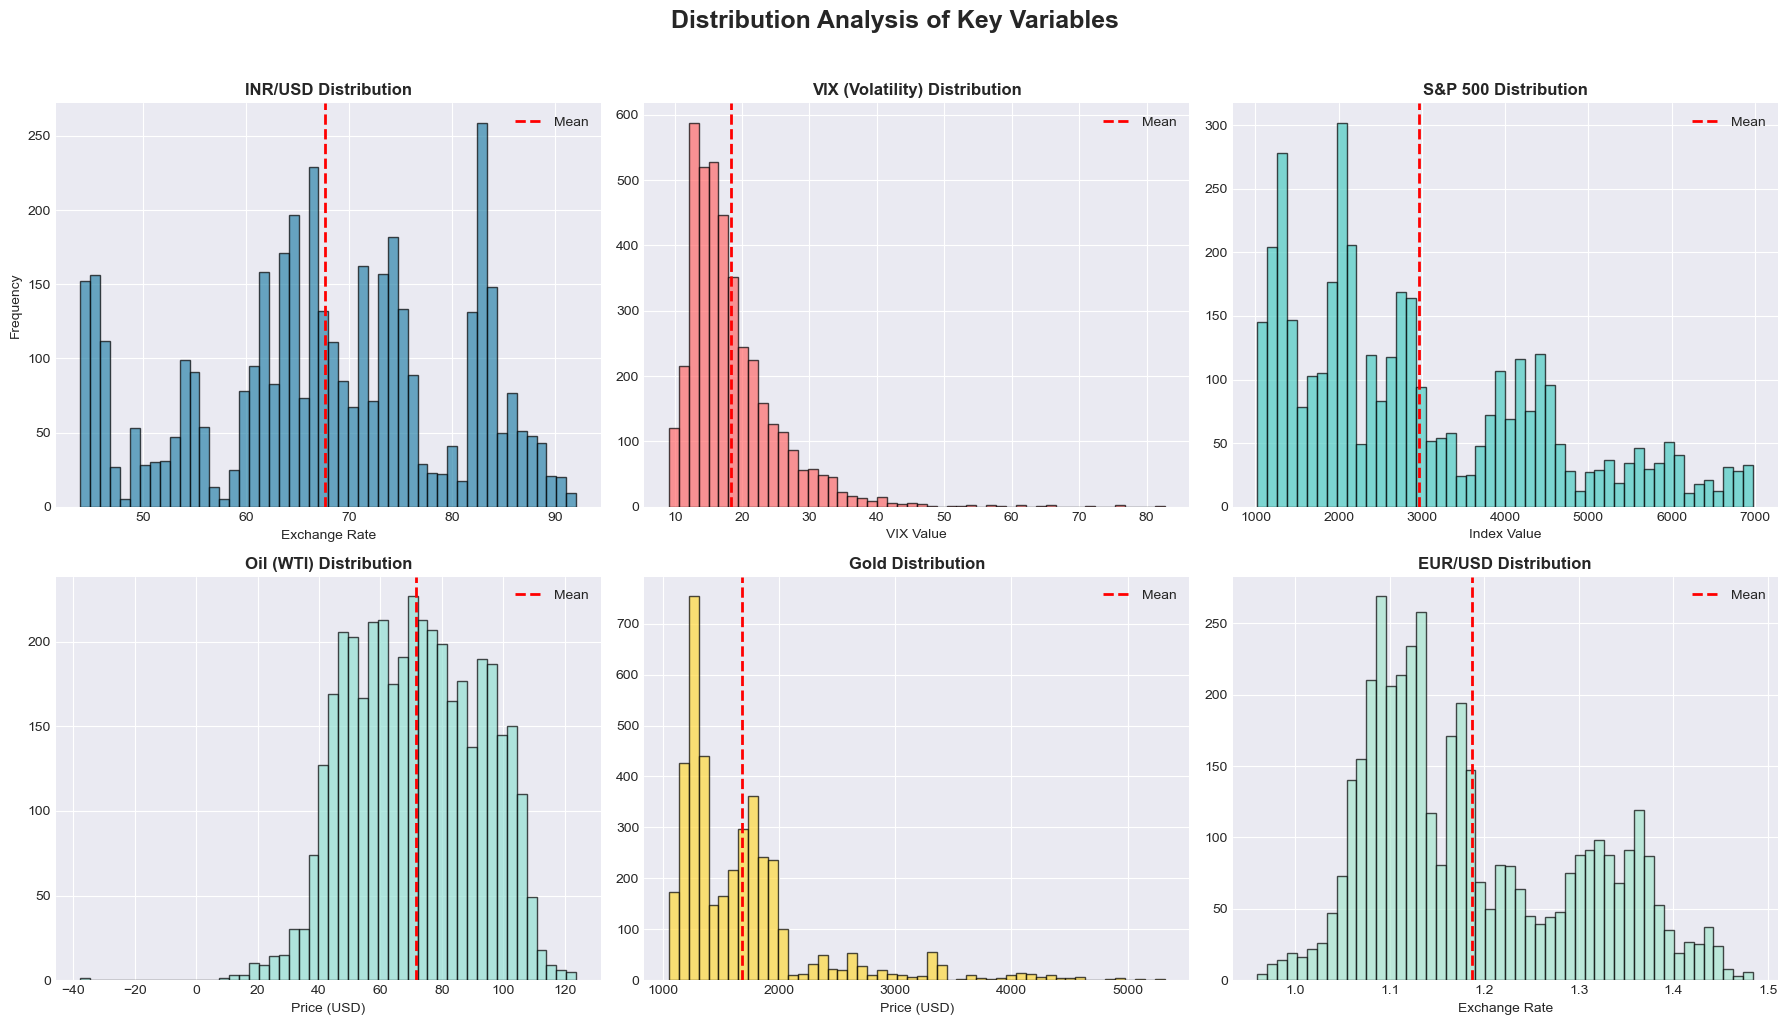

In [7]:
# Create distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution Analysis of Key Variables', 
             fontsize=18, fontweight='bold', y=1.02)

# INR/USD
axes[0, 0].hist(df_currency['INR_USD'], bins=50, 
                color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_currency['INR_USD'].mean(), 
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_title('INR/USD Distribution', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Exchange Rate')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# VIX
axes[0, 1].hist(df_economic['VIX'].dropna(), bins=50, 
                color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_economic['VIX'].mean(), 
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_title('VIX (Volatility) Distribution', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('VIX Value')
axes[0, 1].legend()

# S&P 500
axes[0, 2].hist(df_economic['SP500'].dropna(), bins=50, 
                color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(df_economic['SP500'].mean(), 
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 2].set_title('S&P 500 Distribution', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('Index Value')
axes[0, 2].legend()

# Oil
axes[1, 0].hist(df_commodity['Oil_WTI'].dropna(), bins=50, 
                color='#95E1D3', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df_commodity['Oil_WTI'].mean(), 
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_title('Oil (WTI) Distribution', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Price (USD)')
axes[1, 0].legend()

# Gold
axes[1, 1].hist(df_commodity['Gold'].dropna(), bins=50, 
                color='#FFD93D', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df_commodity['Gold'].mean(), 
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_title('Gold Distribution', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Price (USD)')
axes[1, 1].legend()

# EUR/USD
axes[1, 2].hist(df_currency['EUR_USD'].dropna(), bins=50, 
                color='#A8E6CF', edgecolor='black', alpha=0.7)
axes[1, 2].axvline(df_currency['EUR_USD'].mean(), 
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 2].set_title('EUR/USD Distribution', fontweight='bold', fontsize=12)
axes[1, 2].set_xlabel('Exchange Rate')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

CRISIS vs NORMAL PERIODS ANALYSIS

✓ Matched 4,191 overlapping dates

 Data Split:
  Crisis days: 2,711 (64.7%)
  Normal days: 1,480 (35.3%)

 CRISIS PERIODS:
  Mean: ₹68.14
  Std:  ₹11.97
  Min:  ₹44.01
  Max:  ₹92.04

 NORMAL PERIODS:
  Mean: ₹66.81
  Std:  ₹12.99
  Min:  ₹43.90
  Max:  ₹87.59

 KEY FINDING:
  INR is 1.98% WEAKER during crises


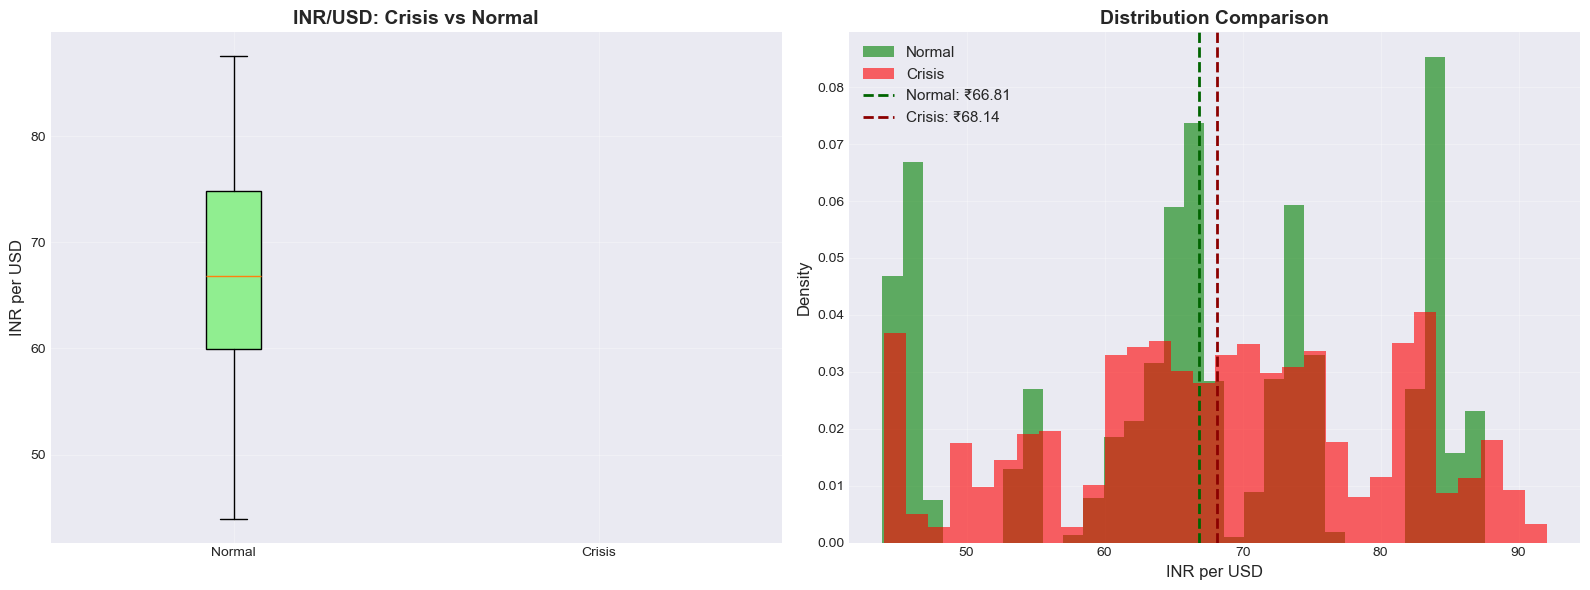


✅ Analysis complete!


In [11]:
# CRISIS vs NORMAL - CLEAN VERSION (No Warnings)

print("="*70)
print("CRISIS vs NORMAL PERIODS ANALYSIS")
print("="*70)

# Merge data on matching dates
combined = df_currency[['INR_USD']].join(df_events['Any_Crisis'], how='inner')

print(f"\n✓ Matched {len(combined):,} overlapping dates")

# Split data
crisis_days = combined[combined['Any_Crisis'] == 1]['INR_USD']
normal_days = combined[combined['Any_Crisis'] == 0]['INR_USD']

print(f"\n Data Split:")
print(f"  Crisis days: {len(crisis_days):,} ({len(crisis_days)/len(combined)*100:.1f}%)")
print(f"  Normal days: {len(normal_days):,} ({len(normal_days)/len(combined)*100:.1f}%)")

# Statistics
print(f"\n CRISIS PERIODS:")
print(f"  Mean: ₹{crisis_days.mean():.2f}")
print(f"  Std:  ₹{crisis_days.std():.2f}")
print(f"  Min:  ₹{crisis_days.min():.2f}")
print(f"  Max:  ₹{crisis_days.max():.2f}")

print(f"\n NORMAL PERIODS:")
print(f"  Mean: ₹{normal_days.mean():.2f}")
print(f"  Std:  ₹{normal_days.std():.2f}")
print(f"  Min:  ₹{normal_days.min():.2f}")
print(f"  Max:  ₹{normal_days.max():.2f}")

# Difference
diff_pct = ((crisis_days.mean() - normal_days.mean()) / normal_days.mean()) * 100

print(f"\n KEY FINDING:")
print(f"  INR is {abs(diff_pct):.2f}% {'WEAKER' if diff_pct > 0 else 'STRONGER'} during crises")

# Visualization - FIXED VERSION
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot - FIXED (using tick_labels instead of labels)
bp = axes[0].boxplot([normal_days, crisis_days], patch_artist=True)
axes[0].set_xticklabels(['Normal', 'Crisis'])  # FIXED LINE
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')

axes[0].set_title('INR/USD: Crisis vs Normal', fontsize=14, fontweight='bold')
axes[0].set_ylabel('INR per USD', fontsize=12)
axes[0].grid(alpha=0.3)

# Histogram
axes[1].hist(normal_days, bins=30, alpha=0.6, label='Normal', color='green', density=True)
axes[1].hist(crisis_days, bins=30, alpha=0.6, label='Crisis', color='red', density=True)
axes[1].axvline(normal_days.mean(), color='darkgreen', linestyle='--', 
                linewidth=2, label=f'Normal: ₹{normal_days.mean():.2f}')
axes[1].axvline(crisis_days.mean(), color='darkred', linestyle='--', 
                linewidth=2, label=f'Crisis: ₹{crisis_days.mean():.2f}')

axes[1].set_title('Distribution Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('INR per USD', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Analysis complete!")

In [10]:
# Create summary statistics
summary = pd.DataFrame({
    'Mean': df_currency.mean(),
    'Std_Dev': df_currency.std(),
    'Min': df_currency.min(),
    'Max': df_currency.max(),
    'Range': df_currency.max() - df_currency.min(),
    'Missing_%': (df_currency.isnull().sum() / len(df_currency) * 100)
})

print("="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(summary)

# Save to CSV
summary.to_csv('E:/Projects/INR_Currency_Project/results/tables/currency_summary.csv')
print("\n✅ Summary saved to: results/tables/currency_summary.csv")

SUMMARY STATISTICS
               Mean    Std_Dev        Min         Max      Range  Missing_%
INR_USD   67.668555  12.357309  43.900002   92.040802  48.140800   0.023861
EUR_USD    1.186383   0.111760   0.959619    1.484406   0.524787   0.023861
GBP_USD    1.404231   0.148185   1.072754    1.716090   0.643336   0.023861
JPY_USD  112.855218  21.902116  75.739998  161.621002  85.881004   0.023861
CNY_USD    6.659743   0.360506   5.863000    7.350000   1.487000   0.071582
AUD_USD    0.791360   0.133133   0.574290    1.103497   0.529207   0.047721

✅ Summary saved to: results/tables/currency_summary.csv
